# CS514 Community Interpretation Notebook

This notebook inspects whether the fine-grained game communities are meaningful.

Current target run:

- Backbone: `merged_ownership_newman_disparity_a0p025`
- Louvain resolution: `1.75`
- Output label: `merged_ownership_newman_disparity_a0p025_r1p75`

The goal is not just to count communities. The goal is to decide whether each community has a recognizable behavioral/taste identity using size, stability, enriched metadata tags, representative games, and graph structure.

## 1. Setup

In [13]:
from pathlib import Path
import json
import math
import sys

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option('display.max_columns', 80)
pd.set_option('display.max_colwidth', 160)
pd.set_option('display.width', 180)
sns.set_theme(style='whitegrid')

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent

OUT = ROOT / 'data' / 'processed' / 'cs514_network_analysis'
DETAILS_CSV = ROOT / 'data' / 'processed' / 'top_ranked_games_details' / 'top_ranked_games_details_top5000_ranked_only' / 'top_ranked_games_details.csv'
SELECTED_GAMES_CSV = ROOT / 'data' / 'processed' / 'reliable_users' / 'reliable_users_batch1' / 'selected_games.csv'

GRAPH_LABEL = 'merged_ownership_newman_disparity_a0p025'
RUN_LABEL = 'merged_ownership_newman_disparity_a0p025_r1p75'

COMMUNITIES_CSV = OUT / 'communities' / f'{RUN_LABEL}_communities.csv'
RUNS_CSV = OUT / 'communities' / f'{RUN_LABEL}_community_runs.csv'
ENRICHMENT_CSV = OUT / 'metadata' / f'{RUN_LABEL}_community_tag_enrichment.csv'
TAG_MODULARITY_CSV = OUT / 'metadata' / f'{RUN_LABEL}_tag_modularity.csv'
BACKBONE_EDGES_CSV = OUT / 'backbones' / f'{GRAPH_LABEL}_edges.csv'
SUMMARY_OUT = OUT / 'metadata' / f'{RUN_LABEL}_community_interpretation_summary.csv'

for path in [COMMUNITIES_CSV, RUNS_CSV, ENRICHMENT_CSV, TAG_MODULARITY_CSV, BACKBONE_EDGES_CSV, DETAILS_CSV, SELECTED_GAMES_CSV]:
    if not path.exists():
        raise FileNotFoundError(path)

print('Project root:', ROOT)
print('Run label:', RUN_LABEL)

Project root: C:\Users\suuser\Desktop\Practices\bgg_project
Run label: merged_ownership_newman_disparity_a0p025_r1p75


## 2. Load Data

In [14]:
communities = pd.read_csv(COMMUNITIES_CSV)
runs = pd.read_csv(RUNS_CSV)
enrichment = pd.read_csv(ENRICHMENT_CSV)
tag_modularity = pd.read_csv(TAG_MODULARITY_CSV)
edges = pd.read_csv(BACKBONE_EDGES_CSV)

selected = pd.read_csv(SELECTED_GAMES_CSV)
details = pd.read_csv(DETAILS_CSV)
games = details[details['bgg_id'].isin(set(selected['bgg_id'].astype(int)))].copy()
games['bgg_id'] = games['bgg_id'].astype(int)

def split_pipe(value):
    if pd.isna(value) or value == '':
        return []
    return [x.strip() for x in str(value).split('|') if x.strip()]

games['mechanics_list'] = games.get('mechanics', pd.Series(index=games.index, dtype=str)).map(split_pipe)
games['categories_list'] = games.get('categories', pd.Series(index=games.index, dtype=str)).map(split_pipe)

comm_games = communities.merge(games, on='bgg_id', how='left', suffixes=('', '_detail'))

print('Communities rows:', len(communities))
print('Unique communities:', communities['community'].nunique())
print('Backbone edges:', len(edges))
display(communities.head())

Communities rows: 2500
Unique communities: 43
Backbone edges: 214379


,bgg_id,community,name,overall_rank
0,224517,7,Brass: Birmingham,1
1,342942,24,Ark Nova,2
2,161936,4,Pandemic Legacy: Season 1,3
3,174430,12,Gloomhaven,4
4,397598,19,Dune: Imperium – Uprising,5


## 3. Stability and Run Diagnostics

A meaningful partition should be reasonably stable across Louvain seeds. We use median pairwise NMI across seeds as the stability diagnostic.

Median pairwise NMI: 0.758
Representative/best run:


,seed,n_communities,modularity,representative,median_pairwise_nmi
12,12.0,43.0,0.076671,True,0.757622


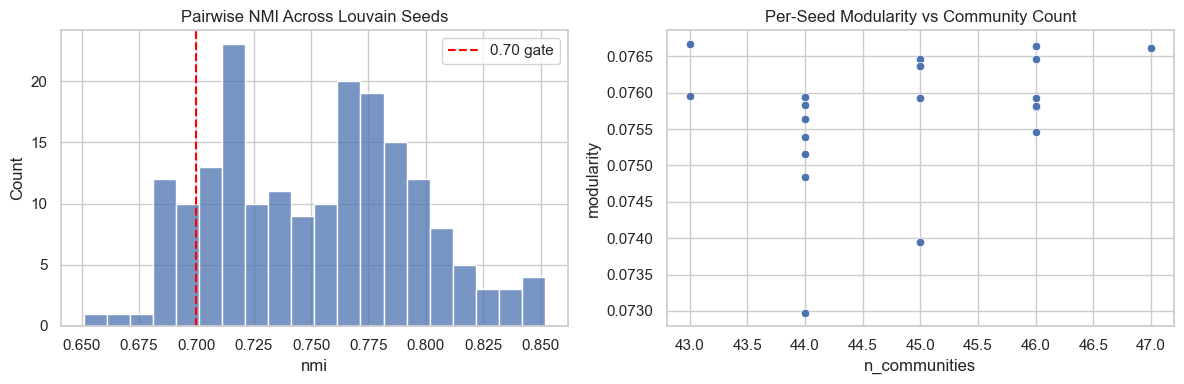

In [15]:
run_rows = runs[runs['level_0'] == 'runs'].copy()
pairwise_rows = runs[runs['level_0'] == 'pairwise'].copy()

median_nmi = pairwise_rows['nmi'].median()
best_run = run_rows.sort_values('modularity', ascending=False).head(1)

print(f'Median pairwise NMI: {median_nmi:.3f}')
print('Representative/best run:')
display(best_run[['seed', 'n_communities', 'modularity', 'representative', 'median_pairwise_nmi']])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(pairwise_rows['nmi'], bins=20, ax=axes[0])
axes[0].axvline(0.70, color='red', linestyle='--', label='0.70 gate')
axes[0].set_title('Pairwise NMI Across Louvain Seeds')
axes[0].legend()

sns.scatterplot(data=run_rows, x='n_communities', y='modularity', ax=axes[1])
axes[1].set_title('Per-Seed Modularity vs Community Count')
plt.tight_layout()

## 4. Community Size Structure

We want enough communities to be useful, but not many tiny meaningless fragments. This section identifies the size profile.

,community,size
count,43.000000,43.000000
mean,21.000000,58.139535
std,12.556539,88.287566
min,0.000000,4.000000
25%,10.500000,7.500000
50%,21.000000,12.000000
75%,31.500000,43.000000
max,42.000000,338.000000


,community,size
10,10,338
9,9,251
12,12,231
19,19,231
2,2,207
20,20,198
25,25,177
13,13,168
8,8,166
35,35,100


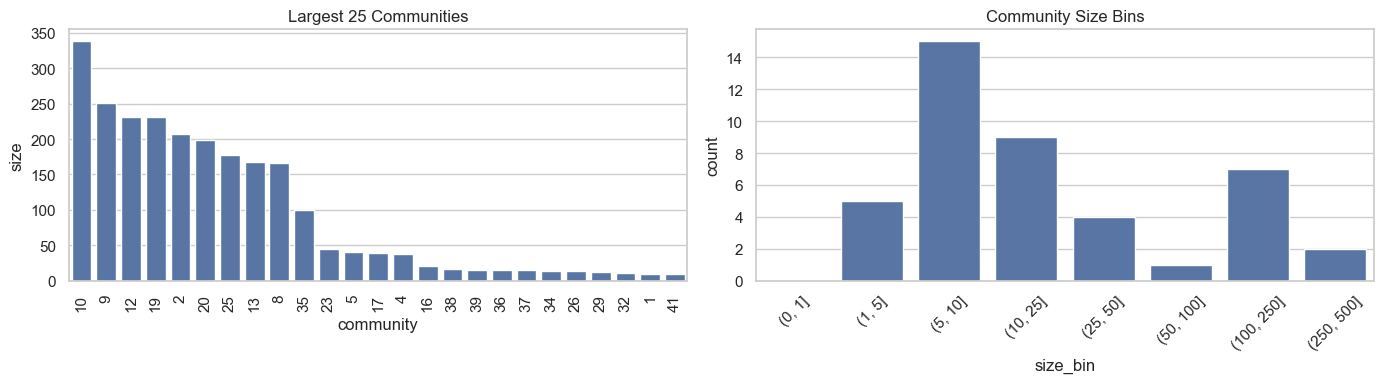

In [16]:
size_df = (
    communities.groupby('community')
    .size()
    .rename('size')
    .reset_index()
    .sort_values('size', ascending=False)
)

display(size_df.describe())
display(size_df.head(60))

bins = [0, 1, 5, 10, 25, 50, 100, 250, 500]
size_df['size_bin'] = pd.cut(size_df['size'], bins=bins, right=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_sizes = size_df.head(25).copy()
plot_sizes['community'] = plot_sizes['community'].astype(str)
sns.barplot(data=plot_sizes, x='community', y='size', order=plot_sizes['community'].tolist(), ax=axes[0])
axes[0].set_title('Largest 25 Communities')
axes[0].tick_params(axis='x', rotation=90)

sns.countplot(data=size_df, x='size_bin', ax=axes[1])
axes[1].set_title('Community Size Bins')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()

## 5. Metadata Enrichment Summary

For semantic meaningfulness, each community should ideally have enriched categories and/or mechanics. We inspect the strongest tags per community.

In [17]:
def top_enriched_tags(community_id, kind=None, n=5, min_observed=2):
    df = enrichment[enrichment['community'].astype(int) == int(community_id)].copy()
    if kind is not None:
        df = df[df['tag_kind'] == kind]
    df = df[df['observed'] >= min_observed]
    df = df.sort_values(['p_value', 'fold_enrichment'], ascending=[True, False])
    return df.head(n)

def join_top_tags(community_id, kind, n=5):
    df = top_enriched_tags(community_id, kind=kind, n=n)
    if df.empty:
        return ''
    return '; '.join(f"{r.tag} ({r.observed}, {float(r.fold_enrichment):.1f}x)" for r in df.itertuples())

enrichment_counts = (
    enrichment[enrichment['p_value'] <= 0.001]
    .groupby(['community', 'tag_kind'])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)
enrichment_counts.columns.name = None
for col in ['mechanic', 'category']:
    if col not in enrichment_counts:
        enrichment_counts[col] = 0

tag_preview_rows = []
for cid in sorted(communities['community'].unique()):
    tag_preview_rows.append({
        'community': cid,
        'size': int(size_df.loc[size_df['community'] == cid, 'size'].iloc[0]),
        'top_categories': join_top_tags(cid, 'category', n=5),
        'top_mechanics': join_top_tags(cid, 'mechanic', n=5),
    })

tag_preview = pd.DataFrame(tag_preview_rows).sort_values('size', ascending=False)
display(tag_preview.head(25))

,community,size,top_categories,top_mechanics
10,10,338,"Abstract Strategy (50, 3.0x); Medieval (49, 1.8x); Ancient (38, 1.9x); Economic (76, 1.5x); Territory Building (37, 1.6x)","Auction / Bidding (62, 3.0x); Enclosure (23, 3.8x); Auction: Turn Order Until Pass (11, 4.3x); Commodity Speculation (16, 3.0x); Static Capture (8, 4.6x)"
9,9,251,"Fighting (131, 3.7x); Miniatures (81, 4.8x); Fantasy (119, 2.2x); Collectible Components (28, 7.3x); Horror (48, 3.8x)","Variable Player Powers (174, 2.4x); Dice Rolling (161, 2.2x); Player Elimination (40, 3.2x); Role Playing (37, 3.3x); Grid Movement (62, 2.3x)"
12,12,231,"Adventure (104, 4.4x); Fantasy (125, 2.5x); Fighting (97, 3.0x); Miniatures (57, 3.7x); Exploration (68, 3.0x)","Cooperative Game (168, 4.4x); Scenario / Mission / Campaign Game (107, 5.1x); Solo / Solitaire Game (156, 3.0x); Variable Player Powers (137, 2.1x); Role Pl..."
19,19,231,"Card Game (112, 1.7x); Animals (46, 2.3x); Party Game (32, 2.4x); Environmental (17, 2.6x); Puzzle (25, 1.8x)","Deduction (27, 3.7x); Trick-taking (16, 4.2x); Communication Limits (20, 2.8x); Closed Drafting (16, 2.3x); Race (25, 1.8x)"
2,2,207,"Industry / Manufacturing (48, 5.0x); Economic (88, 2.8x); City Building (36, 2.2x); Farming (15, 2.3x); Renaissance (13, 2.3x)","End Game Bonuses (86, 3.3x); Worker Placement (85, 3.3x); Income (60, 4.2x); Variable Set-up (76, 2.7x); Worker Placement, Different Worker Types (32, 5.3x)"
20,20,198,"Wargame (122, 7.2x); World War II (45, 8.9x); Political (46, 6.1x); Modern Warfare (14, 9.8x); Napoleonic (10, 10.5x)","Simulation (107, 8.4x); Campaign / Battle Card Driven (52, 6.6x); Dice Rolling (114, 2.0x); Ratio / Combat Results Table (15, 11.8x); Hexagon Grid (52, 3.1x)"
25,25,177,"Party Game (57, 5.6x); Children's Game (26, 8.2x); Deduction (44, 3.6x); Bluffing (33, 3.5x); Real-time (24, 4.0x)","Hidden Roles (19, 4.7x); Memory (20, 4.1x); Voting (18, 3.9x); Acting (8, 7.5x); Elapsed Real Time Ending (8, 7.1x)"
13,13,168,"Animals (48, 3.3x); Puzzle (37, 3.6x); Abstract Strategy (24, 2.9x); Environmental (15, 3.1x); Travel (8, 3.1x)","Set Collection (85, 2.3x); Pattern Building (40, 4.1x); End Game Bonuses (53, 2.5x); Solo / Solitaire Game (72, 1.9x); Contracts (35, 2.8x)"
8,8,166,"Economic (76, 3.0x); Farming (28, 5.3x); Renaissance (18, 4.0x); Industry / Manufacturing (22, 2.9x); Civilization (22, 2.6x)","Worker Placement (77, 3.7x); Turn Order: Claim Action (19, 4.0x); Tile Placement (46, 1.9x); Contracts (28, 2.3x); Turn Order: Progressive (18, 3.0x)"
35,35,100,"Word Game (14, 12.5x); Party Game (27, 4.7x); Deduction (22, 3.2x); Action / Dexterity (9, 4.4x); Card Game (46, 1.6x)","Trick-taking (11, 6.7x); Communication Limits (13, 4.3x); Deduction (13, 4.1x); Targeted Clues (6, 10.0x); Voting (11, 4.2x)"


## 6. Representative Games Per Community

A community is easier to interpret if its top-ranked games and most central games tell the same story as the enriched tags.

In [18]:
rank_col = 'overall_rank'
weight_col = 'average_weight' if 'average_weight' in comm_games.columns else ('weight' if 'weight' in comm_games.columns else None)
year_col = 'year_published' if 'year_published' in comm_games.columns else ('yearpublished' if 'yearpublished' in comm_games.columns else None)

def top_games_by_rank(community_id, n=10):
    cols = ['bgg_id', 'name', 'overall_rank']
    if weight_col and weight_col in comm_games.columns:
        cols.append(weight_col)
    if year_col and year_col in comm_games.columns:
        cols.append(year_col)
    return (
        comm_games[comm_games['community'] == community_id]
        .sort_values('overall_rank')
        [cols]
        .head(n)
    )

def join_top_games(community_id, n=8):
    df = top_games_by_rank(community_id, n=n)
    return '; '.join(f"{r.name} (#{int(r.overall_rank)})" for r in df.itertuples())

game_preview_rows = []
for cid in sorted(communities['community'].unique()):
    group = comm_games[comm_games['community'] == cid]
    row = {
        'community': cid,
        'size': len(group),
        'median_rank': group['overall_rank'].median(),
        'top_games_by_rank': join_top_games(cid, n=8),
    }
    if weight_col and weight_col in group.columns:
        row['median_weight'] = group[weight_col].median()
    if year_col and year_col in group.columns:
        row['median_year'] = group[year_col].median()
    game_preview_rows.append(row)

game_preview = pd.DataFrame(game_preview_rows).sort_values('size', ascending=False)
display(game_preview.head(25))

,community,size,median_rank,top_games_by_rank,median_weight,median_year
10,10,338,1576.5,Puerto Rico (#55); Agricola (#64); Power Grid (#74); El Grande (#100); Ra (#115); Through the Ages: A Story of Civilization (#118); Tigris & Euphrates (#131...,2.31350,2004.0
9,9,251,1197.0,Twilight Imperium: Fourth Edition (#7); Star Wars: Rebellion (#10); Mage Knight Board Game (#39); Blood Rage (#65); Mansions of Madness: Second Edition (#75...,2.71890,2012.0
12,12,231,1151.0,Gloomhaven (#4); Spirit Island (#11); Gloomhaven: Jaws of the Lion (#12); Slay the Spire: The Board Game (#17); Frosthaven (#21); Nemesis (#25); Arkham Horr...,2.71670,2021.0
19,19,231,1300.0,Dune: Imperium – Uprising (#5); The Lord of the Rings: Duel for Middle-earth (#20); Sky Team (#33); Heat: Pedal to the Metal (#47); Clank!: Catacombs (#52);...,1.94440,2023.0
2,2,207,866.0,Gaia Project (#13); SETI: Search for Extraterrestrial Intelligence (#16); A Feast for Odin (#27); Great Western Trail: Second Edition (#31); Barrage (#40); ...,3.39600,2022.0
20,20,198,1387.0,War of the Ring: Second Edition (#8); Twilight Struggle (#14); Brass: Lancashire (#23); Food Chain Magnate (#49); Pax Pamir: Second Edition (#53); Dominant ...,3.55015,2012.0
25,25,177,1502.0,The Resistance: Avalon (#236); Captain Sonar (#245); Secret Hitler (#264); Sushi Go Party! (#286); Deception: Murder in Hong Kong (#289); Santorini (#310); ...,1.47830,2014.0
13,13,168,1396.5,Cascadia (#60); Wingspan Asia (#88); Raiders of the North Sea (#134); PARKS (#175); Cartographers (#179); It's a Wonderful World (#184); Terraforming Mars: ...,2.05810,2021.0
8,8,166,990.0,Through the Ages: A New Story of Civilization (#18); Great Western Trail (#19); Terra Mystica (#35); Orléans (#36); Caverna: The Cave Farmers (#62); Tzolk'i...,2.97755,2014.0
35,35,100,1286.0,The Crew: Mission Deep Sea (#43); Crokinole (#46); Blood on the Clocktower (#68); The Search for Planet X (#114); Decrypto (#117); The Quest for El Dorado (...,1.65965,2018.0


## 7. Build Graph and Compute Community-Level Network Diagnostics

This checks whether communities are graphically cohesive, not only metadata-coherent.

In [19]:
G = nx.Graph()
G.add_nodes_from(communities['bgg_id'].astype(int))
for row in edges.itertuples(index=False):
    G.add_edge(int(row.source), int(row.target), weight=float(row.weight))

community_map = dict(zip(communities['bgg_id'].astype(int), communities['community'].astype(int)))
nx.set_node_attributes(G, community_map, 'community')
name_map = dict(zip(comm_games['bgg_id'].astype(int), comm_games['name'].astype(str)))
nx.set_node_attributes(G, name_map, 'label')

weighted_degree = dict(G.degree(weight='weight'))
degree = dict(G.degree())

def community_graph_stats(community_id):
    nodes = [n for n, c in community_map.items() if c == community_id]
    sub = G.subgraph(nodes)
    internal_weight = sum(d.get('weight', 1.0) for _, _, d in sub.edges(data=True))
    total_incident_weight = sum(weighted_degree.get(n, 0.0) for n in nodes)
    internal_weight_share = (2 * internal_weight / total_incident_weight) if total_incident_weight else np.nan
    return {
        'community': community_id,
        'internal_edges': sub.number_of_edges(),
        'internal_density': nx.density(sub) if len(nodes) > 1 else 0.0,
        'internal_weight': internal_weight,
        'internal_weight_share': internal_weight_share,
        'avg_degree_global': np.mean([degree.get(n, 0) for n in nodes]) if nodes else np.nan,
        'avg_weighted_degree_global': np.mean([weighted_degree.get(n, 0.0) for n in nodes]) if nodes else np.nan,
    }

graph_stats = pd.DataFrame([community_graph_stats(cid) for cid in sorted(communities['community'].unique())])
display(graph_stats.merge(size_df, on='community').sort_values('size', ascending=False).head(25))

,community,internal_edges,internal_density,internal_weight,internal_weight_share,avg_degree_global,avg_weighted_degree_global,size,size_bin
10,10,10394,0.182501,4029.336768,0.325787,159.742604,73.183460,338,"(250, 500]"
9,9,5963,0.190056,2211.823624,0.253862,154.764940,69.424027,251,"(250, 500]"
12,12,4906,0.184679,1941.680207,0.241669,148.168831,69.562299,231,"(100, 250]"
19,19,4382,0.164954,2095.479040,0.229193,153.588745,79.159089,231,"(100, 250]"
2,2,5608,0.263027,3012.761863,0.304043,163.995169,95.739137,207,"(100, 250]"
20,20,5692,0.291853,1740.179404,0.318828,145.631313,55.131882,198,"(100, 250]"
25,25,2572,0.165126,1241.209756,0.163442,160.412429,85.810053,177,"(100, 250]"
13,13,2199,0.156758,951.460744,0.148480,147.678571,76.285997,168,"(100, 250]"
8,8,2638,0.192625,1300.384610,0.189104,151.650602,82.850285,166,"(100, 250]"
35,35,1012,0.204444,475.602854,0.107330,164.080000,88.624028,100,"(50, 100]"


## 8. Central Games Within Each Community

Central games are useful labels because they are strongly connected to other games in the same behavioral community.

In [20]:
def central_games(community_id, n=10):
    nodes = [node for node, cid in community_map.items() if cid == community_id]
    sub = G.subgraph(nodes)
    centrality = dict(sub.degree(weight='weight'))
    out = (
        pd.DataFrame({'bgg_id': list(centrality.keys()), 'internal_weighted_degree': list(centrality.values())})
        .merge(comm_games[['bgg_id', 'name', 'overall_rank', 'community']], on='bgg_id', how='left')
        .sort_values(['internal_weighted_degree', 'overall_rank'], ascending=[False, True])
        .head(n)
    )
    return out

def join_central_games(community_id, n=6):
    df = central_games(community_id, n=n)
    return '; '.join(f"{r.name} ({float(r.internal_weighted_degree):.1f})" for r in df.itertuples())

central_preview = pd.DataFrame([
    {'community': cid, 'central_games': join_central_games(cid, n=6)}
    for cid in sorted(communities['community'].unique())
])
display(central_preview.merge(size_df, on='community').sort_values('size', ascending=False).head(25))

,community,central_games,size,size_bin
10,10,Puerto Rico (225.9); Power Grid (224.8); Bohnanza (208.6); Agricola (202.4); Lost Cities (184.5); Ra (178.1),338,"(250, 500]"
9,9,King of Tokyo (137.4); Star Wars: Rebellion (129.5); Lords of Waterdeep (125.0); Small World (124.2); Blood Rage (117.8); Star Realms (106.1),251,"(250, 500]"
12,12,Spirit Island (183.6); Gloomhaven: Jaws of the Lion (152.1); Gloomhaven (147.7); Arkham Horror: The Card Game (129.0); Robinson Crusoe: Adventures on the Cu...,231,"(100, 250]"
19,19,SCOUT (174.9); Sky Team (167.9); Sea Salt & Paper (160.4); Flip 7 (156.5); Harmonies (149.3); Heat: Pedal to the Metal (145.4),231,"(100, 250]"
2,2,Underwater Cities (148.7); The White Castle (146.4); Gaia Project (144.8); Barrage (143.7); A Feast for Odin (143.1); SETI: Search for Extraterrestrial Inte...,207,"(100, 250]"
20,20,Twilight Struggle (143.0); Brass: Lancashire (83.4); War of the Ring: Second Edition (77.9); Food Chain Magnate (76.2); Pax Pamir: Second Edition (75.2); Do...,198,"(100, 250]"
25,25,Dixit (124.6); Hanabi (116.5); Sushi Go! (101.4); Coup (97.3); Takenoko (89.0); Forbidden Island (88.9),177,"(100, 250]"
13,13,Cascadia (135.8); Sagrada (98.2); Cartographers (92.9); Welcome To... (84.1); Earth (70.0); PARKS (67.4),168,"(100, 250]"
8,8,Tzolk'in: The Mayan Calendar (120.9); Orléans (107.9); Le Havre (99.5); Great Western Trail (99.3); Terra Mystica (98.5); Caverna: The Cave Farmers (95.2),166,"(100, 250]"
35,35,The Mind (59.6); The Crew: Mission Deep Sea (59.5); The Quest for El Dorado (57.0); Decrypto (52.0); Arboretum (50.1); Codenames: Duet (49.1),100,"(50, 100]"


## 9. One-Community Drilldown

Change `COMMUNITY_ID` and rerun the cell to inspect a specific community in detail.

In [21]:
COMMUNITY_ID = int(size_df.iloc[0]['community'])
print('Inspecting community:', COMMUNITY_ID)
print('Size:', int(size_df.loc[size_df['community'] == COMMUNITY_ID, 'size'].iloc[0]))

print('\nTop enriched categories:')
display(top_enriched_tags(COMMUNITY_ID, kind='category', n=10))

print('\nTop enriched mechanics:')
display(top_enriched_tags(COMMUNITY_ID, kind='mechanic', n=10))

print('\nTop games by BGG rank:')
display(top_games_by_rank(COMMUNITY_ID, n=25))

print('\nCentral games by internal weighted degree:')
display(central_games(COMMUNITY_ID, n=25))

Inspecting community: 10
Size: 338

Top enriched categories:


,community,tag_kind,tag,observed,community_size,tag_total,expected,fold_enrichment,p_value,rank_in_community_kind
596,10,category,Abstract Strategy,50,338,125,16.9000,2.958580,2.886370e-14,1.0
597,10,category,Medieval,49,338,200,27.0400,1.812130,8.777314e-06,2.0
598,10,category,Ancient,38,338,151,20.4152,1.861358,5.306585e-05,3.0
599,10,category,Economic,76,338,380,51.3760,1.479290,8.243225e-05,4.0
600,10,category,Territory Building,37,338,166,22.4432,1.648606,9.318301e-04,5.0
601,10,category,Transportation,20,338,73,9.8696,2.026425,1.098627e-03,6.0
602,10,category,City Building,40,338,200,27.0400,1.479290,5.027034e-03,7.0
603,10,category,Religious,6,338,19,2.5688,2.335721,3.387557e-02,8.0
604,10,category,Racing,9,338,37,5.0024,1.799136,5.285874e-02,9.0
605,10,category,Maze,5,338,16,2.1632,2.311391,5.385876e-02,10.0



Top enriched mechanics:


,community,tag_kind,tag,observed,community_size,tag_total,expected,fold_enrichment,p_value,rank_in_community_kind
657,10,mechanic,Auction / Bidding,62,338,155,20.9560,2.958580,1.320090e-17,1.0
658,10,mechanic,Enclosure,23,338,45,6.0840,3.780408,1.244824e-09,2.0
659,10,mechanic,Auction: Turn Order Until Pass,11,338,19,2.5688,4.282155,6.494248e-06,3.0
660,10,mechanic,Commodity Speculation,16,338,40,5.4080,2.958580,2.539897e-05,4.0
661,10,mechanic,Static Capture,8,338,13,1.7576,4.551661,7.159029e-05,5.0
662,10,mechanic,Area Majority / Influence,83,338,426,57.5952,1.441092,9.566928e-05,6.0
663,10,mechanic,Auction: Once Around,7,338,14,1.8928,3.698225,1.136642e-03,7.0
664,10,mechanic,Stock Holding,13,338,39,5.2728,2.465483,1.181751e-03,8.0
665,10,mechanic,Map Reduction,9,338,22,2.9744,3.025820,1.335866e-03,9.0
666,10,mechanic,Score-and-Reset Game,15,338,51,6.8952,2.175426,2.132610e-03,10.0



Top games by BGG rank:


,bgg_id,name,overall_rank,average_weight,year_published
54,3076,Puerto Rico,55,3.2666,2002
63,31260,Agricola,64,3.6352,2007
73,2651,Power Grid,74,3.2466,2004
99,93,El Grande,100,2.9338,1995
114,12,Ra,115,2.3066,1999
117,25613,Through the Ages: A Story of Civilization,118,4.1780,2006
130,42,Tigris & Euphrates,131,3.4784,1997
131,40834,Dominion: Intrigue,132,2.4103,2009
137,18602,Caylus,138,3.7908,2005
146,43015,Hansa Teutonica,147,3.0907,2009



Central games by internal weighted degree:


,bgg_id,internal_weighted_degree,name,overall_rank,community
202,3076,225.929209,Puerto Rico,55,10
142,2651,224.832931,Power Grid,74,10
6,11,208.639497,Bohnanza,544,10
131,31260,202.378484,Agricola,64,10
24,50,184.528450,Lost Cities,344,10
7,12,178.061919,Ra,115,10
60,172,157.502354,For Sale,355,10
119,478,156.264483,Citadels,584,10
148,12942,151.978366,No Thanks!,552,10
17,42,149.386114,Tigris & Euphrates,131,10


## 10. Build Interpretation Summary CSV

This table is intended for manual inspection. Add labels/notes in a copy if needed.

In [22]:
summary = (
    size_df[['community', 'size']]
    .merge(tag_preview[['community', 'top_categories', 'top_mechanics']], on='community', how='left')
    .merge(game_preview.drop(columns=['size']), on='community', how='left')
    .merge(graph_stats, on='community', how='left')
    .merge(central_preview, on='community', how='left')
    .merge(enrichment_counts[['community', 'category', 'mechanic']], on='community', how='left')
)
summary[['category', 'mechanic']] = summary[['category', 'mechanic']].fillna(0).astype(int)
summary = summary.rename(columns={
    'category': 'n_strong_category_enrichments_p001',
    'mechanic': 'n_strong_mechanic_enrichments_p001',
})

def rough_meaningfulness(row):
    strong_tags = row['n_strong_category_enrichments_p001'] + row['n_strong_mechanic_enrichments_p001']
    if row['size'] >= 20 and strong_tags >= 3:
        return 'high_candidate'
    if row['size'] >= 10 and strong_tags >= 1:
        return 'medium_candidate'
    if row['size'] < 6:
        return 'tiny_fragment'
    return 'needs_manual_review'

summary['rough_meaningfulness_flag'] = summary.apply(rough_meaningfulness, axis=1)
summary['manual_label'] = ''
summary['manual_notes'] = ''

summary = summary.sort_values(['size', 'community'], ascending=[False, True])
SUMMARY_OUT.parent.mkdir(parents=True, exist_ok=True)
summary.to_csv(SUMMARY_OUT, index=False)

print('Wrote:', SUMMARY_OUT)
display(summary.head(30))

Wrote: C:\Users\suuser\Desktop\Practices\bgg_project\data\processed\cs514_network_analysis\metadata\merged_ownership_newman_disparity_a0p025_r1p75_community_interpretation_summary.csv


,community,size,top_categories,top_mechanics,median_rank,top_games_by_rank,median_weight,median_year,internal_edges,internal_density,internal_weight,internal_weight_share,avg_degree_global,avg_weighted_degree_global,central_games,n_strong_category_enrichments_p001,n_strong_mechanic_enrichments_p001,rough_meaningfulness_flag,manual_label,manual_notes
0,10,338,"Abstract Strategy (50, 3.0x); Medieval (49, 1.8x); Ancient (38, 1.9x); Economic (76, 1.5x); Territory Building (37, 1.6x)","Auction / Bidding (62, 3.0x); Enclosure (23, 3.8x); Auction: Turn Order Until Pass (11, 4.3x); Commodity Speculation (16, 3.0x); Static Capture (8, 4.6x)",1576.5,Puerto Rico (#55); Agricola (#64); Power Grid (#74); El Grande (#100); Ra (#115); Through the Ages: A Story of Civilization (#118); Tigris & Euphrates (#131...,2.31350,2004.0,10394,0.182501,4029.336768,0.325787,159.742604,73.183460,Puerto Rico (225.9); Power Grid (224.8); Bohnanza (208.6); Agricola (202.4); Lost Cities (184.5); Ra (178.1),5,6,high_candidate,,
1,9,251,"Fighting (131, 3.7x); Miniatures (81, 4.8x); Fantasy (119, 2.2x); Collectible Components (28, 7.3x); Horror (48, 3.8x)","Variable Player Powers (174, 2.4x); Dice Rolling (161, 2.2x); Player Elimination (40, 3.2x); Role Playing (37, 3.3x); Grid Movement (62, 2.3x)",1197.0,Twilight Imperium: Fourth Edition (#7); Star Wars: Rebellion (#10); Mage Knight Board Game (#39); Blood Rage (#65); Mansions of Madness: Second Edition (#75...,2.71890,2012.0,5963,0.190056,2211.823624,0.253862,154.764940,69.424027,King of Tokyo (137.4); Star Wars: Rebellion (129.5); Lords of Waterdeep (125.0); Small World (124.2); Blood Rage (117.8); Star Realms (106.1),16,18,high_candidate,,
2,12,231,"Adventure (104, 4.4x); Fantasy (125, 2.5x); Fighting (97, 3.0x); Miniatures (57, 3.7x); Exploration (68, 3.0x)","Cooperative Game (168, 4.4x); Scenario / Mission / Campaign Game (107, 5.1x); Solo / Solitaire Game (156, 3.0x); Variable Player Powers (137, 2.1x); Role Pl...",1151.0,Gloomhaven (#4); Spirit Island (#11); Gloomhaven: Jaws of the Lion (#12); Slay the Spire: The Board Game (#17); Frosthaven (#21); Nemesis (#25); Arkham Horr...,2.71670,2021.0,4906,0.184679,1941.680207,0.241669,148.168831,69.562299,Spirit Island (183.6); Gloomhaven: Jaws of the Lion (152.1); Gloomhaven (147.7); Arkham Horror: The Card Game (129.0); Robinson Crusoe: Adventures on the Cu...,12,20,high_candidate,,
3,19,231,"Card Game (112, 1.7x); Animals (46, 2.3x); Party Game (32, 2.4x); Environmental (17, 2.6x); Puzzle (25, 1.8x)","Deduction (27, 3.7x); Trick-taking (16, 4.2x); Communication Limits (20, 2.8x); Closed Drafting (16, 2.3x); Race (25, 1.8x)",1300.0,Dune: Imperium – Uprising (#5); The Lord of the Rings: Duel for Middle-earth (#20); Sky Team (#33); Heat: Pedal to the Metal (#47); Clank!: Catacombs (#52);...,1.94440,2023.0,4382,0.164954,2095.479040,0.229193,153.588745,79.159089,SCOUT (174.9); Sky Team (167.9); Sea Salt & Paper (160.4); Flip 7 (156.5); Harmonies (149.3); Heat: Pedal to the Metal (145.4),4,3,high_candidate,,
4,2,207,"Industry / Manufacturing (48, 5.0x); Economic (88, 2.8x); City Building (36, 2.2x); Farming (15, 2.3x); Renaissance (13, 2.3x)","End Game Bonuses (86, 3.3x); Worker Placement (85, 3.3x); Income (60, 4.2x); Variable Set-up (76, 2.7x); Worker Placement, Different Worker Types (32, 5.3x)",866.0,Gaia Project (#13); SETI: Search for Extraterrestrial Intelligence (#16); A Feast for Odin (#27); Great Western Trail: Second Edition (#31); Barrage (#40); ...,3.39600,2022.0,5608,0.263027,3012.761863,0.304043,163.995169,95.739137,Underwater Cities (148.7); The White Castle (146.4); Gaia Project (144.8); Barrage (143.7); A Feast for Odin (143.1); SETI: Search for Extraterrestrial Inte...,3,20,high_candidate,,
5,20,198,"Wargame (122, 7.2x); World War II (45, 8.9x); Political (46, 6.1x); Modern Warfare (14, 9.8x); Napoleonic (10, 10.5x)","Simulation (107, 8.4x); Campaign / Battle Card Driven (52, 6.6x); Dice Rolling (114, 2.0x); Ratio / Combat Results Table (15, 11.8

## 11. Communities That Need Manual Attention

These are small, weakly enriched, or otherwise ambiguous communities. They are not necessarily bad, but they should not become headline findings without inspection.

In [23]:
attention = summary[summary['rough_meaningfulness_flag'].isin(['tiny_fragment', 'needs_manual_review'])]
print('Communities needing manual attention:', len(attention))
display(attention[['community', 'size', 'rough_meaningfulness_flag', 'top_categories', 'top_mechanics', 'top_games_by_rank']].head(40))

Communities needing manual attention: 20


,community,size,rough_meaningfulness_flag,top_categories,top_mechanics,top_games_by_rank
23,1,10,needs_manual_review,"Movies / TV / Radio theme (3, 8.2x); Card Game (6, 2.1x); Horror (2, 4.0x); Science Fiction (3, 2.4x); Fantasy (4, 1.8x)","Narrative Choice / Paragraph (2, 8.6x); Worker Placement, Different Worker Types (2, 6.8x); Turn Order: Progressive (2, 5.6x); Storytelling (2, 4.8x); Hand ...",Lost Ruins of Arnak (#30); Star Wars: Unlimited (#634); My Father's Work (#691); AuZtralia (#830); Star Wars: Jabba's Palace – A Love Letter Game (#1327); D...
26,3,9,needs_manual_review,"Industry / Manufacturing (2, 4.8x); Civilization (2, 4.3x); Science Fiction (3, 2.7x); Economic (3, 2.2x)","Take That (5, 5.8x); Worker Placement (5, 4.5x); Tech Trees / Tech Tracks (3, 8.4x); End Game Bonuses (4, 3.6x); Card Play Conflict Resolution (2, 6.2x)",Scythe (#26); Western Legends (#285); The Godfather: Corleone's Empire (#449); Euphoria: Build a Better Dystopia (#687); Lovecraft Letter (#942); Era: Medie...
25,14,9,needs_manual_review,"Abstract Strategy (4, 8.9x); Puzzle (2, 3.7x); Territory Building (2, 3.3x); Animals (2, 2.6x); Fantasy (2, 1.0x)","Layering (3, 14.4x); Pattern Building (4, 7.7x); Tile Placement (5, 3.8x); Chaining (2, 15.0x); End Game Bonuses (4, 3.6x)",Azul (#96); Ginkgopolis (#427); Dragon Castle (#880); Cat Lady (#1179); Miyabi (#1668); Terra Nova (#1773); Adventure Land (#1959); Sanssouci (#1984)
24,41,9,needs_manual_review,"Trains (6, 24.5x); Nautical (2, 5.1x); Territory Building (2, 3.3x)","Network and Route Building (6, 10.4x); Set Collection (7, 3.5x); Open Drafting (6, 3.1x); Connections (2, 10.9x); Map Addition (2, 9.1x)",Ticket to Ride: Europe (#178); Ticket to Ride: Nordic Countries (#238); Ticket to Ride: Rails & Sails (#805); Ticket to Ride: London (#1159); Ticket to Ride...
28,15,8,needs_manual_review,"Civilization (3, 7.3x); Ancient (3, 6.2x); Space Exploration (2, 7.3x); Medieval (2, 3.1x); Science Fiction (2, 2.0x)","Delayed Purchase (2, 13.9x); Deck, Bag, and Pool Building (3, 3.8x); Modular Board (3, 2.5x); Hand Management (5, 1.7x); Open Drafting (3, 1.7x)",Dominion (#145); Imhotep (#618); Eminent Domain (#937); Luxor (#1020); The Duke (#1024); Core Worlds (#1188); Imhotep: The Duel (#1524); Catan Histories: Se...
27,24,8,needs_manual_review,"Environmental (2, 8.7x); Card Game (5, 2.2x); Territory Building (2, 3.8x); Animals (2, 2.9x); Fantasy (2, 1.1x)","Set Collection (6, 3.4x); Grid Coverage (2, 9.1x); Open Drafting (4, 2.3x); Income (2, 3.7x); Tile Placement (3, 2.5x)",Ark Nova (#2); The Pursuit of Happiness (#941); Roam (#1000); Ecos: First Continent (#1181); Carnival of Monsters (#1491); Museum (#1651); Dice Settlers (#1...
30,27,8,needs_manual_review,"Space Exploration (3, 10.9x); Science Fiction (3, 3.0x); Card Game (4, 1.7x); Fantasy (3, 1.7x)","Follow (2, 17.4x); Variable Phase Order (2, 7.7x); Tags (2, 7.4x); Multi-Use Cards (2, 5.5x); Race (2, 4.2x)",Race for the Galaxy (#93); Millennium Blades (#523); Argent: The Consortium (#635); New Frontiers (#886); Jump Drive (#1223); Automobiles (#1294); Onirim (#...
31,28,8,needs_manual_review,"Real-time (3, 11.2x); Movies / TV / Radio theme (2, 6.8x); Party Game (2, 4.3x); Deduction (2, 3.7x); Card Game (2, 0.9x)","Action Timer (2, 208.3x); Real-Time (3, 17.4x); Communication Limits (2, 8.2x); Deduction (2, 7.8x); Cooperative Game (3, 2.3x)",Just One (#156); Awkward Guests: The Walton Case (#396); Kitchen Rush (#1131); Paper Tales (#1214); Rush M.D. (#2052); Ubongo 3D (#2071); Time's Up! Edición...
29,40,8,needs_manual_review,"Abstract Strategy (2, 5.0x); Puzzle (2, 4.1x); Territory Building (2, 3.8x); Medieval (2, 3.1x); Card Game (4, 1.7x)","Turn Order: Claim Action (3, 13.0x); Open Drafting (6, 3.4x); Enclosure (2, 13.9x); Worker Placement (3, 3.0x); Set Collection (4, 2.3x)",Kingdomino (#329); Downforce (#508); Queendomino (#706); Fabled Fruit (#1150); World's Fair 1893 (#1207); Mint Works (#1279); A Game of Thrones: Hand of the...
33,11,7,